In [1]:
from tensorflow.keras import backend as K
K.clear_session()

In [2]:
!pip install rarfile

In [3]:
import os
import pandas as pd
import gdown
import rarfile
import shutil
from PIL import Image
# Download the RAR file
url = 'https://drive.google.com/uc?id=1uh58eeyRUqagxTSlnPyVDaVvoKYIuC95'
#https://drive.google.com/file/d/1uh58eeyRUqagxTSlnPyVDaVvoKYIuC95/view?usp=drive_link
output_rar = '/content/Enhanced_Leguminosae_3C_Dataset.rar'
gdown.download(url, output_rar, quiet=False)
# Extract the RAR file
with rarfile.RarFile(output_rar, 'r') as rar_ref:
    rar_ref.extractall('/content')

Downloading...
From: https://drive.google.com/uc?id=1uh58eeyRUqagxTSlnPyVDaVvoKYIuC95
To: /content/Enhanced_Leguminosae_3C_Dataset.rar
100%|██████████| 14.8M/14.8M [00:00<00:00, 17.9MB/s]


In [4]:
# Path to the extracted dataset folder
dataset_Tomato = '/content/Enhanced_Leguminosae_3C_Dataset'

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 224, 224, 64)   │          1,792 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 224, 224, 64)   │            256 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 112, 112, 64)   │          1,792 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 224, 224, 64)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 112, 112, 64)   │            256 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 112, 112, 64)   │              0 │ activation[0][0]       │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 112, 112, 64)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 112, 112, 128)  │              0 │ max_pooling2d[0][0],   │
│                           │                        │                │ activation_1[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 112, 112, 64)   │          8,256 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 112, 112, 64)   │         36,928 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 56, 56, 32)     │          2,432 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 112, 112, 64)   │            256 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 56, 56, 64)     │         36,928 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 56, 56, 32)     │            128 │ conv2d_5[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 112, 112, 64)   │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3

 Total params: 890,244 (3.40 MB)

 Trainable params: 889,668 (3.39 MB)

 Non-trainable params: 576 (2.25 KB)

Found 621 images belonging to 4 classes.
Found 87 images belonging to 4 classes.
Found 181 images belonging to 4 classes.
Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 47s 962ms/step - accuracy: 0.3814 - loss: 1.3568 - val_accuracy: 0.2529 - val_loss: 1.3834
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 127ms/step - accuracy: 0.5939 - loss: 1.0247 - val_accuracy: 0.2529 - val_loss: 1.3801
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - accuracy: 0.6670 - loss: 0.8646 - val_accuracy: 0.2529 - val_loss: 1.4008
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - accuracy: 0.6976 - loss: 0.7610 - val_accuracy: 0.2529 - val_loss: 1.4619
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.6856 - loss: 0.8006 - val_accuracy: 0.2529 - val_loss: 1.6661
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - accuracy: 0.7518 - loss: 0.6344 - val_accuracy: 0.2529 - val_loss: 2.1391
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.7471 - loss: 0.6019 - val_accuracy: 0.2529 - val_loss: 2.7750
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.7552 - loss: 0.5681 - val_accuracy: 0.2529 - va

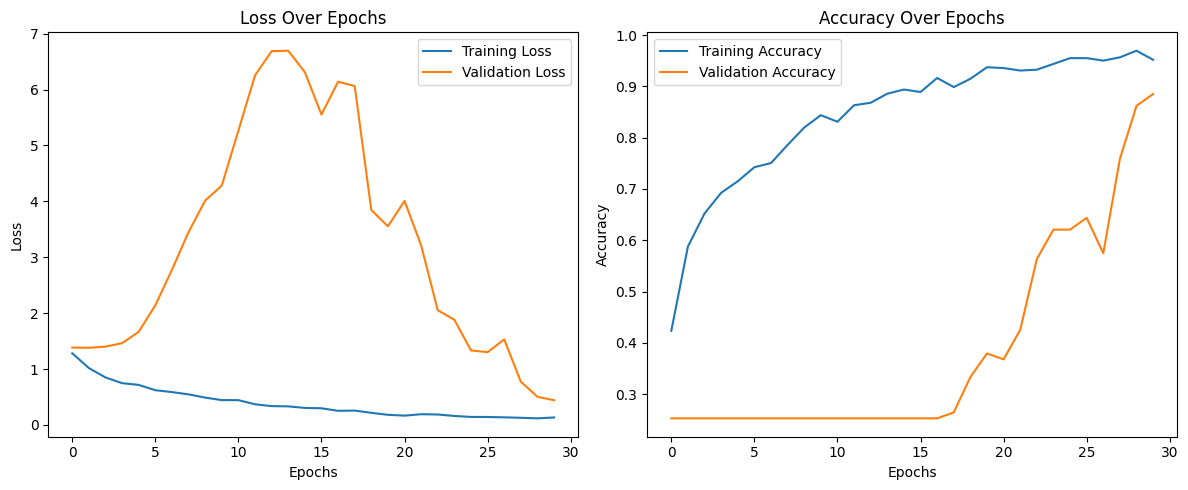

6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 586ms/step

Performance on Test Data [Using Model_2-swish]
Precision: 0.866050578402591
Recall: 0.861878453038674
F1 Score: 0.8602694205484731
Accuracy: 0.861878453038674
Confusion Matrix:
                      Acacia_Modesta  Albizia_Lebbeck  Bauhinia_Variegatav  \
Acacia_Modesta                   34                5                    0   
Albizia_Lebbeck                   2               34                    1   
Bauhinia_Variegatav               0                0                   45   
Unknown                           1                1                    3   

                     Unknown  
Acacia_Modesta             6  
Albizia_Lebbeck            6  
Bauhinia_Variegatav        0  
Unknown                   43  


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import random
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from sklearn.model_selection import KFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, Add, GlobalAveragePooling2D, Flatten, Dense
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Directory for the dataset
data_dir = dataset_Tomato

# Define the CNN architecture



# Define the CNN architecture
input_shape = (224, 224, 3)
num_classes = 4

# Input
inputs = layers.Input(shape=input_shape)

# LLF Net#1
a1 = layers.Conv2D(64, (3, 3), strides=(1, 1), padding='same')(inputs)
a1 = layers.BatchNormalization()(a1)
a1 = layers.Activation('swish')(a1)
MPa1 = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(a1)

b1 = layers.Conv2D(64, (3, 3), strides=(2, 2), padding='same')(inputs)
b1 = layers.BatchNormalization()(b1)
b1 = layers.Activation('swish')(b1)
a1b1 = layers.Concatenate()([MPa1, b1])
a1b1 = layers.Conv2D(64, (1, 1), strides=(1, 1), padding='same')(a1b1)

a2 = layers.Conv2D(64, (3, 3), strides=(1, 1), padding='same')(a1b1)
a2 = layers.BatchNormalization()(a2)
a2 = layers.Activation('swish')(a2)
MPa2 = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(a2)

b2 = layers.Conv2D(64, (3, 3), strides=(2, 2), padding='same')(a1b1)
b2 = layers.BatchNormalization()(b2)
b2 = layers.Activation('swish')(b2)

c1 = layers.Conv2D(32, (5, 5), strides=(4, 4), padding='same')(inputs)
c1 = layers.BatchNormalization()(c1)
c1 = layers.Activation('swish')(c1)
c1a2b2 = layers.Concatenate()([c1, MPa2, b2])

Net1 = layers.Conv2D(64, (1, 1), strides=(1, 1), padding='same')(c1a2b2)

BLock1 = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(Net1)
x=BLock1
# Block2 Inception
inception1_1 = Conv2D(128, (1, 1), activation='swish')(x)
inception1_3 = Conv2D(128, (1, 1), activation='swish')(x)
inception1_3 = Conv2D(192, (3, 3), activation='swish', padding='same')(inception1_3)
inception1_5 = Conv2D(32, (1, 1), activation='swish')(x)
inception1_5 = Conv2D(96, (5, 5), activation='swish', padding='same')(inception1_5)
inception1_7 = MaxPooling2D(pool_size=(3, 3), strides=(1, 1), padding='same')(x)
inception1_7 = Conv2D(64, (1, 1), activation='swish')(inception1_7)
Incp2 = layers.Concatenate()([inception1_1, inception1_3, inception1_5, inception1_7])
Incp2  = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(Incp2)
x = Incp2
# Block3 Inception
inception1_1 = Conv2D(128, (1, 1), activation='swish')(x)
inception1_3 = Conv2D(128, (1, 1), activation='swish')(x)
inception1_3 = Conv2D(192, (3, 3), activation='swish', padding='same')(inception1_3)
inception1_5 = Conv2D(32, (1, 1), activation='swish')(x)
inception1_5 = Conv2D(96, (5, 5), activation='swish', padding='same')(inception1_5)
inception1_7 = MaxPooling2D(pool_size=(3, 3), strides=(1, 1), padding='same')(x)
inception1_7 = Conv2D(64, (1, 1), activation='swish')(inception1_7)
Incp3 = layers.Concatenate()([inception1_1, inception1_3, inception1_5, inception1_7])
Incp3  = layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(Incp3)
x = Incp3
# Global Average Pooling (GAP)
global_avg_pool = layers.GlobalAveragePooling2D()(x)
# Fully Connected Layer
outputs = layers.Dense(num_classes, activation='softmax')(global_avg_pool)

# Create the model
model = tf.keras.Model(inputs=inputs, outputs=outputs)
model.summary()
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])


# ImageDataGenerators
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Data generators for training, validation, and testing
train_generator = train_datagen.flow_from_directory(
    os.path.join(data_dir, 'Train'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(data_dir, 'Validate'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(data_dir, 'Test'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='sparse',
    shuffle=False
)

# Training the model
history = model.fit(train_generator, epochs=30, validation_data=val_generator)

# Plot training results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Helper function to evaluate the model on given test generator
def evaluate_model(test_generator, model, classes, title="Performance"):
    y_test_pred = model.predict(test_generator)
    y_test_pred = np.argmax(y_test_pred, axis=1)

    precision = precision_score(test_generator.labels, y_test_pred, average='weighted')
    recall = recall_score(test_generator.labels, y_test_pred, average='weighted')
    f1 = f1_score(test_generator.labels, y_test_pred, average='weighted')
    accuracy = accuracy_score(test_generator.labels, y_test_pred)

    print(f"\n{title}")
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("Accuracy:", accuracy)

    # Display the confusion matrix
    confusion = confusion_matrix(test_generator.labels, y_test_pred)
    confusion_df = pd.DataFrame(confusion, index=classes, columns=classes)
    print("Confusion Matrix:\n", confusion_df)

# Test the model on the test set
evaluate_model(test_generator, model, ['Acacia_Modesta', 'Albizia_Lebbeck', 'Bauhinia_Variegatav', 'Unknown'], title="Performance on Test Data [Using Model_2-swish]")


In [6]:
import numpy as np

def calculate_confusion_metrics_and_scores(conf_matrix, class_labels):
    """
    Calculate TP, FP, FN, TN, Precision, Recall, and F1-Score for each class in a confusion matrix.

    Parameters:
    - conf_matrix (numpy.ndarray): The confusion matrix
    - class_labels (list): List of class labels corresponding to the matrix

    Returns:
    - metrics (dict): A dictionary containing TP, FP, FN, TN, Precision, Recall, F1-Score for each class
    """
    num_classes = len(class_labels)
    metrics = {label: {'TP': 0, 'FP': 0, 'FN': 0, 'TN': 0, 'Precision': 0, 'Recall': 0, 'F1-Score': 0} for label in class_labels}

    for i in range(num_classes):
        # True Positive: diagonal element
        TP = conf_matrix[i, i]

        # False Positive: sum of the column excluding the diagonal element
        FP = np.sum(conf_matrix[:, i]) - TP

        # False Negative: sum of the row excluding the diagonal element
        FN = np.sum(conf_matrix[i, :]) - TP

        # True Negative: sum of all elements excluding the current row and column
        TN = np.sum(conf_matrix) - (TP + FP + FN)

        # Precision, Recall, and F1-Score calculations
        precision = TP / (TP + FP)*100 if (TP + FP) > 0 else 0
        recall = TP / (TP + FN)*100 if (TP + FN) > 0 else 0
        f1_score = (2 * precision * recall) / (precision + recall)*100 if (precision + recall) > 0 else 0

        # Update metrics for the current class
        metrics[class_labels[i]] = {
            'TP': TP,
            'FP': FP,
            'FN': FN,
            'TN': TN,
            'Precision': precision,
            'Recall': round(recall, 2),  # Round recall to 2 decimal places
            'F1-Score': round(f1_score, 4)  # Limit F1-Score to four decimal places
        }

    return metrics

# Example 10x10 confusion matrix with values provided earlier
conf_matrix_10x10 = np.array([
    [407, 11, 0, 2, 0, 0, 0, 0, 0, 7],   # Bacterial_spot
    [0, 196, 0, 1, 0, 0, 0, 0, 3, 0],   # Early_blight
    [0, 0, 318, 0, 0, 0, 0, 1, 0, 0],   # Healthy
    [0, 7, 2, 373, 1, 0, 0, 0, 0, 0],   # Late_blight
    [0, 1, 0, 1, 189, 0, 0, 0, 0, 4],   # Leaf_Mold
    [0, 0, 0, 0, 1, 73, 0, 0, 1, 0],    # Mosaic_virus
    [0, 7, 0, 1, 2, 0, 342, 0, 3, 0],   # Septoria_leaf_spot
    [0, 0, 1, 0, 0, 1, 0, 330, 3, 1],   # Spider_mites Two-spotted_spider_mite
    [3, 2, 0, 0, 0, 0, 1, 2, 271, 3],    # Target_Spot
    [2, 0, 0, 0, 0, 0, 0, 1, 0, 1070]    # Tomato_Yellow_Leaf_Curl_Virus
])

# Define the class labels for 10 classes
labels_10 = [
    'Bacterial_spot', 'Early_blight', 'Healthy',
    'Late_blight', 'Leaf_Mold', 'Mosaic_virus',
    'Septoria_leaf_spot', 'Spider_mites Two-spotted_spider_mite',
    'Target_Spot', 'Tomato_Yellow_Leaf_Curl_Virus'
]

# Calculate confusion matrix metrics and performance scores
metrics = calculate_confusion_metrics_and_scores(conf_matrix_10x10, labels_10)

# Display the results
for class_label, values in metrics.items():
    print(f"Class: {class_label}")
    print(f"TP: {values['TP']}, FP: {values['FP']}, FN: {values['FN']}, TN: {values['TN']}")
    print(f"Precision: {values['Precision']:.2f}%, Recall: {values['Recall']:.2f}%, F1-Score: {values['F1-Score']:.2f}")
    print("-" * 100)


Class: Bacterial_spot
TP: 407, FP: 5, FN: 20, TN: 3213
Precision: 98.79%, Recall: 95.32%, F1-Score: 9702.03
----------------------------------------------------------------------------------------------------
Class: Early_blight
TP: 196, FP: 28, FN: 4, TN: 3417
Precision: 87.50%, Recall: 98.00%, F1-Score: 9245.28
----------------------------------------------------------------------------------------------------
Class: Healthy
TP: 318, FP: 3, FN: 1, TN: 3323
Precision: 99.07%, Recall: 99.69%, F1-Score: 9937.50
----------------------------------------------------------------------------------------------------
Class: Late_blight
TP: 373, FP: 5, FN: 10, TN: 3257
Precision: 98.68%, Recall: 97.39%, F1-Score: 9802.89
----------------------------------------------------------------------------------------------------
Class: Leaf_Mold
TP: 189, FP: 4, FN: 6, TN: 3446
Precision: 97.93%, Recall: 96.92%, F1-Score: 9742.27
---------------------------------------------------------------------------